# Conflict-Induced Food Crisis Prediction — Task 2: Feature Engineering and EDA

## Overview

Task 1 produced a clean panel dataset with **14,697 region-month observations** across **12 countries** and **211 admin-level-1 regions** (2018-02 to 2023-10, crisis rate 33.1%).
This notebook transforms that panel into a model-ready feature set and performs EDA.

### Key changes vs previous version
| Metric | Old (v4) | New (FINAL) |
|---|---|---|
| Rows | 17,296 | 14,697 |
| Countries | 15 | 12 |
| Regions | 362 | 211 |
| Crisis rate | 55.6% (inflated) | 33.1% (real IPC labels) |
| Date range | 2020-02–2023-12 | 2018-02–2023-10 |
| Train period | 2020-05–2021-12 | 2018-02–2021-12 |
| scale_pos_weight | ~0.8 | 2.0 |

### What this notebook produces
| File | Description |
|---|---|
| `features_engineered.csv` | Full panel with all engineered features |
| `X_train.csv`, `y_train.csv` | Training: 2018-02 to 2021-12 |
| `X_val.csv`, `y_val.csv` | Validation: 2022-01 to 2022-12 |
| `X_test.csv`, `y_test.csv` | Test: 2023-01 to 2023-10 (sealed) |
| `features_manifest.csv` | Every feature documented |
| `eda_charts.png` | Six-panel EDA visualization |
| `split_report.json` | Split sizes, crisis rates, leakage audit |

---
## Step 1 — Restore Backup and Import

In [ ]:
from google.colab import drive
import shutil
from pathlib import Path

if not Path('/content/drive').exists():
    drive.mount('/content/drive')
else:
    print('Google Drive already mounted.')

source_dir = Path('/content/drive/MyDrive/crisis_outputs_backup')
dest_dir   = Path('/content/crisis_outputs')
dest_dir.mkdir(parents=True, exist_ok=True)

if source_dir.exists() and not any(dest_dir.iterdir()):
    print(f'Restoring from {source_dir} ...')
    for item in source_dir.iterdir():
        d = dest_dir / item.name
        shutil.copytree(str(item), str(d), dirs_exist_ok=True) if item.is_dir() else shutil.copy2(str(item), str(d))
    print('Restore complete.')
else:
    print(f'Files already present in {dest_dir} — skipping restore.')

Google Drive already mounted.
Files already present in /content/crisis_outputs — skipping restore.


In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)

OUTPUT_DIR = Path('/content/crisis_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

panel = pd.read_csv(OUTPUT_DIR / 'panel_dataset.csv')
with open(OUTPUT_DIR / 'data_quality_report.json') as f:
    quality_report = json.load(f)

print(f'Panel loaded     : {len(panel):,} rows x {panel.shape[1]} columns')
print(f'Countries        : {panel["country"].nunique()}')
print(f'Regions          : {panel["admin1"].nunique()}')
print(f'Date range       : {panel["year_month"].min()} to {panel["year_month"].max()}')
print(f'Crisis rate      : {panel["crisis_90d"].mean()*100:.1f}%')
print(f'Class imbalance  : {(1-panel["crisis_90d"].mean())/panel["crisis_90d"].mean():.1f}:1 (safe:crisis)')
print(f'Columns          : {panel.columns.tolist()}')

Panel loaded     : 14,697 rows x 20 columns
Countries        : 12
Regions          : 211
Date range       : 2018-02 to 2023-10
Crisis rate      : 33.1%
Class imbalance  : 2.0:1 (safe:crisis)
Columns          : ['country', 'admin1', 'year_month', 'ipc_phase', 'population_in_crisis', 'crisis_90d', 'ipc_lag1', 'ipc_lag2', 'fatalities_30d', 'events_30d', 'battle_events', 'civilian_violence', 'conflict_trend', 'rainfall_mm', 'rainfall_anomaly', 'is_drought', 'is_flood', 'is_lean_season', 'is_harvest_season', 'year']


---
## Step 2 — Temporal Lag Feature Engineering

A conflict event in month T does not immediately cause food insecurity. The causal chain takes 2–3 months:
conflict disrupts planting → harvest failure → market access collapse → IPC phase escalation.

Lag features give the model the ability to learn these delayed effects.
Rolling windows capture cumulative conflict intensity — three consecutive violent months
are far more predictive than a single spike.

In [ ]:
panel = panel.sort_values(['country', 'admin1', 'year_month']).reset_index(drop=True)

def add_lag_features(df):
    grp = df.groupby(['country', 'admin1'])

    # Conflict lags (1, 2, 3 months back)
    for lag in [1, 2, 3]:
        df[f'fatalities_lag{lag}'] = grp['fatalities_30d'].shift(lag)
        df[f'events_lag{lag}']     = grp['events_30d'].shift(lag)

    # Rolling conflict intensity (using prior months only — no leakage)
    df['fatalities_roll2'] = grp['fatalities_30d'].transform(
        lambda x: x.shift(1).rolling(2, min_periods=1).mean())
    df['fatalities_roll3'] = grp['fatalities_30d'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df['events_roll3'] = grp['events_30d'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean())

    # Conflict escalation signals
    df['fatalities_delta'] = grp['fatalities_30d'].diff(1)
    df['fatalities_accel'] = grp['fatalities_delta'].diff(1)

    # Rainfall lags
    df['rainfall_lag1'] = grp['rainfall_anomaly'].shift(1)
    df['rainfall_lag2'] = grp['rainfall_anomaly'].shift(2)
    df['rainfall_roll3'] = grp['rainfall_anomaly'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean())

    # IPC trend (slope of ipc_phase over prior 3 months)
    df['ipc_trend'] = grp['ipc_phase'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=2).apply(
            lambda w: np.polyfit(range(len(w)), w, 1)[0] if len(w) >= 2 else 0
        )
    )

    return df

panel = add_lag_features(panel)

new_cols = [c for c in panel.columns
            if any(x in c for x in ['lag', 'roll', 'delta', 'accel', 'trend'])]
print(f'Lag/rolling features added : {len(new_cols)}')
print(f'Feature list               : {new_cols}')
print(f'Panel shape after lags     : {panel.shape}')

Lag/rolling features added : 18
Feature list               : ['ipc_lag1', 'ipc_lag2', 'conflict_trend', 'fatalities_lag1', 'events_lag1', 'fatalities_lag2', 'events_lag2', 'fatalities_lag3', 'events_lag3', 'fatalities_roll2', 'fatalities_roll3', 'events_roll3', 'fatalities_delta', 'fatalities_accel', 'rainfall_lag1', 'rainfall_lag2', 'rainfall_roll3', 'ipc_trend']
Panel shape after lags     : (14697, 35)


---
## Step 3 — Compound Risk and Interaction Features

Conflict + drought simultaneously collapses both food production AND market access.
Neither feature alone captures this synergy — explicit interaction terms are required.

In [ ]:
fat_median = panel['fatalities_30d'].median()
fat_max    = panel['fatalities_30d'].quantile(0.95) + 1e-6
dry_min    = panel['rainfall_anomaly'].min()
dry_range  = panel['rainfall_anomaly'].max() - dry_min + 1e-6

panel['high_conflict']         = (panel['fatalities_30d'] > fat_median).astype(int)
panel['high_conflict_drought'] = (
    (panel['high_conflict'] == 1) & (panel['is_drought'] == 1)
).astype(int)

panel['conflict_intensity_norm'] = (panel['fatalities_30d'] / fat_max).clip(0, 1)
panel['drought_severity_norm']   = (-(panel['rainfall_anomaly'] - dry_min) / dry_range).clip(0, 1)
panel['compound_risk_score']     = (
    panel['conflict_intensity_norm'] * 0.6 +
    panel['drought_severity_norm']   * 0.4
)

panel['battle_share'] = np.where(
    panel['events_30d'] > 0,
    panel['battle_events'] / panel['events_30d'],
    0.0
)

panel['sustained_conflict'] = (
    (panel['fatalities_lag1'].fillna(0) > 0) &
    (panel['fatalities_lag2'].fillna(0) > 0)
).astype(int)

panel['month'] = panel['year_month'].str[-2:].astype(int)

print('Compound and interaction features added.')
print(f'Panel shape  : {panel.shape}')
print(f'\nCompound risk stats:')
print(f'  High conflict + drought months : {panel["high_conflict_drought"].sum():,} ({panel["high_conflict_drought"].mean()*100:.1f}%)')
print(f'  Sustained conflict months      : {panel["sustained_conflict"].sum():,} ({panel["sustained_conflict"].mean()*100:.1f}%)')
print(f'  Mean compound risk score       : {panel["compound_risk_score"].mean():.3f}')

Compound and interaction features added.
Panel shape  : (14697, 43)

Compound risk stats:
  High conflict + drought months : 1,658 (11.3%)
  Sustained conflict months      : 5,084 (34.6%)
  Mean compound risk score       : 0.074


---
## Step 4 — Feature Catalogue and Selection

We document every feature with its source and correlation with the target.
For a humanitarian AI system, this auditable record is required for transparency.

In [ ]:
FEATURE_COLS = [
    # IPC history — strongest predictors (0.78 corr from Task 1)
    'ipc_lag1', 'ipc_lag2', 'ipc_trend',
    # Conflict — current month
    'fatalities_30d', 'events_30d', 'battle_events',
    'civilian_violence', 'conflict_trend', 'battle_share',
    # Conflict — lagged
    'fatalities_lag1', 'fatalities_lag2', 'fatalities_lag3',
    'events_lag1', 'events_lag2',
    # Conflict — rolling
    'fatalities_roll2', 'fatalities_roll3', 'events_roll3',
    'fatalities_delta', 'fatalities_accel',
    # Compound conflict-drought
    'high_conflict', 'high_conflict_drought',
    'compound_risk_score', 'sustained_conflict',
    # Rainfall
    'rainfall_anomaly', 'is_drought', 'rainfall_lag1',
    'rainfall_lag2', 'rainfall_roll3',
    # Seasonal
    'is_lean_season', 'is_harvest_season', 'month',
]

TARGET_COL = 'crisis_90d'

missing = [f for f in FEATURE_COLS if f not in panel.columns]
if missing:
    print(f'MISSING features — fix required: {missing}')
else:
    print(f'All {len(FEATURE_COLS)} features verified present.')

SOURCES = {
    'ipc_lag1':              'FEWS NET (lag)',
    'ipc_lag2':              'FEWS NET (lag)',
    'ipc_trend':             'FEWS NET (derived)',
    'fatalities_30d':        'ACLED',
    'events_30d':            'ACLED',
    'battle_events':         'ACLED',
    'civilian_violence':     'ACLED',
    'conflict_trend':        'ACLED (derived)',
    'battle_share':          'ACLED (derived)',
    'fatalities_lag1':       'ACLED (lag)',
    'fatalities_lag2':       'ACLED (lag)',
    'fatalities_lag3':       'ACLED (lag)',
    'events_lag1':           'ACLED (lag)',
    'events_lag2':           'ACLED (lag)',
    'fatalities_roll2':      'ACLED (rolling)',
    'fatalities_roll3':      'ACLED (rolling)',
    'events_roll3':          'ACLED (rolling)',
    'fatalities_delta':      'ACLED (derived)',
    'fatalities_accel':      'ACLED (derived)',
    'high_conflict':         'ACLED (derived)',
    'high_conflict_drought': 'ACLED+CHIRPS (interaction)',
    'compound_risk_score':   'ACLED+CHIRPS (interaction)',
    'sustained_conflict':    'ACLED (derived)',
    'rainfall_anomaly':      'CHIRPS',
    'is_drought':            'CHIRPS',
    'rainfall_lag1':         'CHIRPS (lag)',
    'rainfall_lag2':         'CHIRPS (lag)',
    'rainfall_roll3':        'CHIRPS (rolling)',
    'is_lean_season':        'FAO calendar',
    'is_harvest_season':     'FAO calendar',
    'month':                 'Calendar',
}

panel_clean = panel[
    FEATURE_COLS + [TARGET_COL] + ['year_month', 'country', 'admin1', 'ipc_phase']
].dropna().reset_index(drop=True)

print(f'\nRows after dropna: {len(panel_clean):,} (from {len(panel):,})')
print(f'Crisis rate after dropna: {panel_clean[TARGET_COL].mean()*100:.1f}%')

manifest_rows = []
for feat in FEATURE_COLS:
    corr = panel_clean[feat].corr(panel_clean[TARGET_COL])
    manifest_rows.append({
        'feature':     feat,
        'source':      SOURCES.get(feat, 'Unknown'),
        'corr_target': round(corr, 4),
        'abs_corr':    round(abs(corr), 4),
        'dtype':       str(panel_clean[feat].dtype),
        'mean':        round(panel_clean[feat].mean(), 4),
        'std':         round(panel_clean[feat].std(), 4),
        'missing_pct': round(panel[feat].isnull().mean() * 100, 2),
    })

manifest = pd.DataFrame(manifest_rows).sort_values('abs_corr', ascending=False)
manifest.to_csv(OUTPUT_DIR / 'features_manifest.csv', index=False)

print(f'\nTop 15 features by |correlation| with crisis_90d:')
print(manifest[['feature', 'source', 'corr_target']].head(15).to_string(index=False))
print(f'\nFeatures manifest saved: features_manifest.csv')

All 31 features verified present.

Rows after dropna: 14,058 (from 14,697)
Crisis rate after dropna: 33.2%

Top 15 features by |correlation| with crisis_90d:
            feature                     source  corr_target
           ipc_lag1             FEWS NET (lag)       0.7779
           ipc_lag2             FEWS NET (lag)       0.7574
compound_risk_score ACLED+CHIRPS (interaction)       0.3017
 sustained_conflict            ACLED (derived)       0.2672
       battle_share            ACLED (derived)       0.2660
       events_roll3            ACLED (rolling)       0.2630
   fatalities_roll3            ACLED (rolling)       0.2570
        events_lag2                ACLED (lag)       0.2496
        events_lag1                ACLED (lag)       0.2438
         events_30d                      ACLED       0.2399
   fatalities_roll2            ACLED (rolling)       0.2388
  civilian_violence                      ACLED       0.2366
      high_conflict            ACLED (derived)       0.2287
  

---
## Step 5 — Walk-Forward Train / Validation / Test Split

**Why temporal ordering is mandatory:**
Standard k-fold shuffles rows — training on Oct 2022 while validating on Mar 2021 causes future leakage.
Walk-forward enforces strict temporal ordering:

- **Train**: 2018-02 to 2021-12 (expanded from v4 — uses full historical data)
- **Validate**: 2022-01 to 2022-12 (hyperparameter and threshold tuning)
- **Test**: 2023-01 to 2023-10 (sealed — opened only in Task 4)

Three assertions verify no leakage between splits.

In [ ]:
train_mask = panel_clean['year_month'] <= '2021-12'
val_mask   = (panel_clean['year_month'] >= '2022-01') & (panel_clean['year_month'] <= '2022-12')
test_mask  = panel_clean['year_month'] >= '2023-01'

X_train = panel_clean.loc[train_mask, FEATURE_COLS]
y_train = panel_clean.loc[train_mask, TARGET_COL]
X_val   = panel_clean.loc[val_mask,   FEATURE_COLS]
y_val   = panel_clean.loc[val_mask,   TARGET_COL]
X_test  = panel_clean.loc[test_mask,  FEATURE_COLS]
y_test  = panel_clean.loc[test_mask,  TARGET_COL]

# Strict leakage assertions
train_periods = set(panel_clean.loc[train_mask, 'year_month'])
val_periods   = set(panel_clean.loc[val_mask,   'year_month'])
test_periods  = set(panel_clean.loc[test_mask,  'year_month'])

assert len(train_periods & val_periods)  == 0, 'LEAK: Train/val overlap'
assert len(train_periods & test_periods) == 0, 'LEAK: Train/test overlap'
assert len(val_periods   & test_periods) == 0, 'LEAK: Val/test overlap'

spw = (1 - y_train.mean()) / y_train.mean()

print('Temporal split (walk-forward):')
print(f'  Train : {len(X_train):,} rows  '
      f'({panel_clean.loc[train_mask,"year_month"].min()} to '
      f'{panel_clean.loc[train_mask,"year_month"].max()})  '
      f'crisis rate: {y_train.mean()*100:.1f}%')
print(f'  Val   : {len(X_val):,} rows  '
      f'({panel_clean.loc[val_mask,"year_month"].min()} to '
      f'{panel_clean.loc[val_mask,"year_month"].max()})  '
      f'crisis rate: {y_val.mean()*100:.1f}%')
print(f'  Test  : {len(X_test):,} rows  '
      f'({panel_clean.loc[test_mask,"year_month"].min()} to '
      f'{panel_clean.loc[test_mask,"year_month"].max()})  '
      f'crisis rate: {y_test.mean()*100:.1f}%')
print(f'\nLeakage audit: PASSED — no temporal overlap between any splits')
print(f'scale_pos_weight (from train): {spw:.2f}  → use in XGBoost Task 3')

X_train.to_csv(OUTPUT_DIR / 'X_train.csv', index=False)
y_train.to_csv(OUTPUT_DIR / 'y_train.csv', index=False)
X_val.to_csv(OUTPUT_DIR / 'X_val.csv',     index=False)
y_val.to_csv(OUTPUT_DIR / 'y_val.csv',     index=False)
X_test.to_csv(OUTPUT_DIR / 'X_test.csv',   index=False)
y_test.to_csv(OUTPUT_DIR / 'y_test.csv',   index=False)
print('\nAll splits saved. X_test / y_test are SEALED until Task 4.')

Temporal split (walk-forward):
  Train : 9,372 rows  (2018-05 to 2021-12)  crisis rate: 28.2%
  Val   : 2,556 rows  (2022-01 to 2022-12)  crisis rate: 41.4%
  Test  : 2,130 rows  (2023-01 to 2023-10)  crisis rate: 45.6%

Leakage audit: PASSED — no temporal overlap between any splits
scale_pos_weight (from train): 2.54  → use in XGBoost Task 3

All splits saved. X_test / y_test are SEALED until Task 4.


---
## Step 6 — Exploratory Data Analysis

Six-panel EDA visualization covering:
1. Crisis rate over time
2. Crisis rate by country
3. IPC phase distribution
4. Fatality distribution (crisis vs safe)
5. Compound risk score distribution
6. Feature correlation heatmap (top 12)

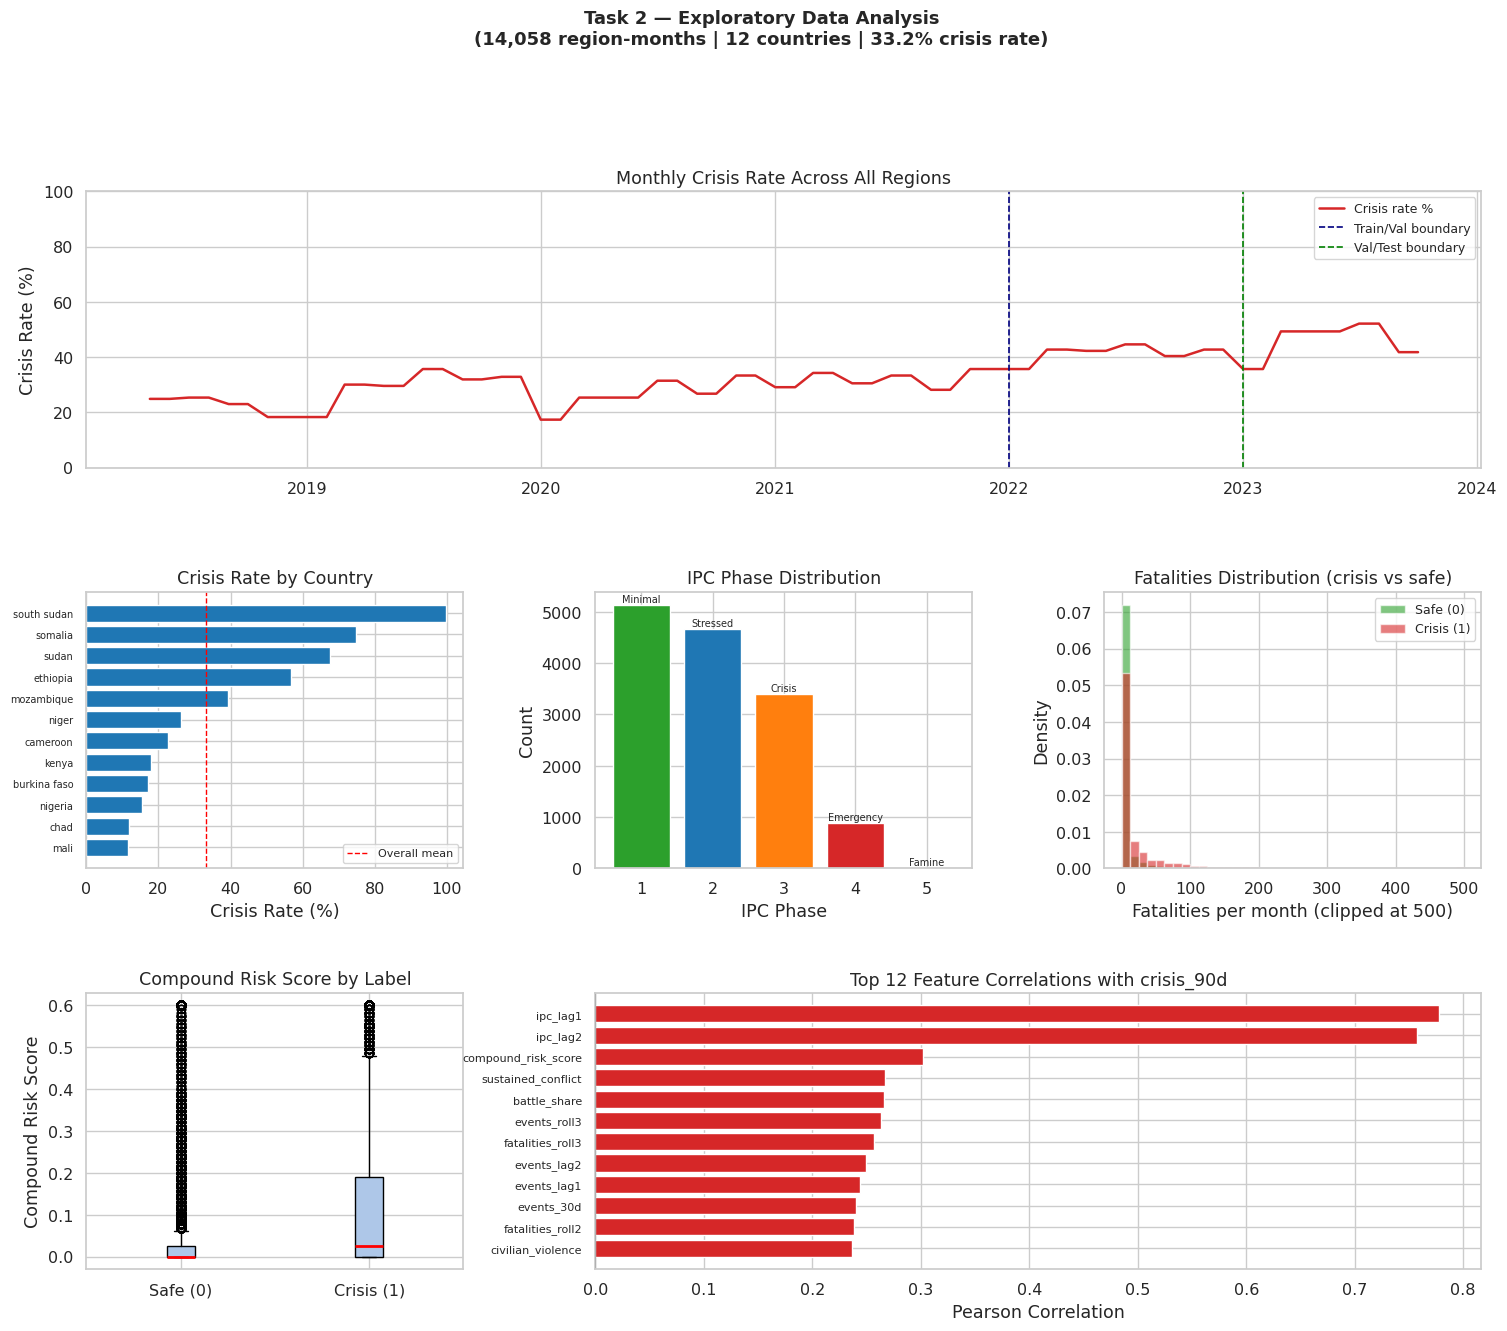

Saved: eda_charts.png


In [ ]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Crisis rate over time
ax1 = fig.add_subplot(gs[0, :])
monthly_cr = (
    panel_clean.groupby('year_month')[TARGET_COL]
    .mean()
    .reset_index()
)
monthly_cr['year_month_dt'] = pd.to_datetime(monthly_cr['year_month'] + '-01')
ax1.plot(monthly_cr['year_month_dt'], monthly_cr[TARGET_COL] * 100,
         color='#d62728', linewidth=1.8, label='Crisis rate %')
ax1.axvline(pd.to_datetime('2022-01-01'), color='navy',  ls='--', lw=1.2, label='Train/Val boundary')
ax1.axvline(pd.to_datetime('2023-01-01'), color='green', ls='--', lw=1.2, label='Val/Test boundary')
ax1.set(title='Monthly Crisis Rate Across All Regions',
        ylabel='Crisis Rate (%)', xlabel='')
ax1.legend(fontsize=9)
ax1.set_ylim(0, 100)

# 2. Crisis rate by country
ax2 = fig.add_subplot(gs[1, 0])
cr_country = (
    panel_clean.groupby('country')[TARGET_COL]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
ax2.barh(cr_country['country'], cr_country[TARGET_COL] * 100, color='#1f77b4')
ax2.axvline(panel_clean[TARGET_COL].mean() * 100, color='red', ls='--', lw=1, label='Overall mean')
ax2.set(title='Crisis Rate by Country', xlabel='Crisis Rate (%)')
ax2.tick_params(axis='y', labelsize=7)
ax2.legend(fontsize=8)

# 3. IPC phase distribution
ax3 = fig.add_subplot(gs[1, 1])
ipc_counts = panel_clean['ipc_phase'].value_counts().sort_index()
colors_ipc = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd']
bars = ax3.bar(ipc_counts.index, ipc_counts.values,
               color=colors_ipc[:len(ipc_counts)])
ax3.set(title='IPC Phase Distribution', xlabel='IPC Phase', ylabel='Count')
ipc_labels = {1: 'Minimal', 2: 'Stressed', 3: 'Crisis', 4: 'Emergency', 5: 'Famine'}
for bar, phase in zip(bars, ipc_counts.index):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             ipc_labels.get(phase, ''), ha='center', va='bottom', fontsize=7)

# 4. Fatality distribution by crisis label
ax4 = fig.add_subplot(gs[1, 2])
fat_safe   = panel_clean.loc[panel_clean[TARGET_COL] == 0, 'fatalities_30d'].clip(upper=500)
fat_crisis = panel_clean.loc[panel_clean[TARGET_COL] == 1, 'fatalities_30d'].clip(upper=500)
ax4.hist(fat_safe,   bins=40, alpha=0.6, color='#2ca02c', label='Safe (0)',   density=True)
ax4.hist(fat_crisis, bins=40, alpha=0.6, color='#d62728', label='Crisis (1)', density=True)
ax4.set(title='Fatalities Distribution (crisis vs safe)',
        xlabel='Fatalities per month (clipped at 500)', ylabel='Density')
ax4.legend(fontsize=9)

# 5. Compound risk score by label
ax5 = fig.add_subplot(gs[2, 0])
ax5.boxplot(
    [panel_clean.loc[panel_clean[TARGET_COL] == 0, 'compound_risk_score'],
     panel_clean.loc[panel_clean[TARGET_COL] == 1, 'compound_risk_score']],
    labels=['Safe (0)', 'Crisis (1)'],
    patch_artist=True,
    boxprops=dict(facecolor='#aec7e8'),
    medianprops=dict(color='red', linewidth=2)
)
ax5.set(title='Compound Risk Score by Label', ylabel='Compound Risk Score')

# 6. Top feature correlations
ax6 = fig.add_subplot(gs[2, 1:])
top_feats = manifest.head(12)['feature'].tolist()
corr_data = panel_clean[top_feats + [TARGET_COL]].corr()[[TARGET_COL]].drop(TARGET_COL)
corr_data.columns = ['corr_with_crisis_90d']
corr_data = corr_data.sort_values('corr_with_crisis_90d')
colors_bar = ['#d62728' if v > 0 else '#1f77b4' for v in corr_data['corr_with_crisis_90d']]
ax6.barh(corr_data.index, corr_data['corr_with_crisis_90d'], color=colors_bar)
ax6.axvline(0, color='black', lw=0.8)
ax6.set(title='Top 12 Feature Correlations with crisis_90d',
        xlabel='Pearson Correlation')
ax6.tick_params(axis='y', labelsize=8)

plt.suptitle('Task 2 — Exploratory Data Analysis\n'
             f'({len(panel_clean):,} region-months | 12 countries | '
             f'{panel_clean[TARGET_COL].mean()*100:.1f}% crisis rate)',
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig(OUTPUT_DIR / 'eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_charts.png')

---
## Step 7 — Feature Importance Pre-Screen

A lightweight 100-tree Random Forest on the training set gives a model-based importance ranking
before any hyperparameter tuning. This identifies which features are worth keeping vs dropping
before Task 3, and validates that ipc_lag1 dominates as expected from the 0.78 correlation.

Running feature importance pre-screen (100-tree Random Forest on train set)...

Top 15 features by Random Forest importance:
  ipc_lag1                     0.386146
  ipc_lag2                     0.292188
  ipc_trend                    0.120242
  fatalities_roll3             0.022495
  fatalities_roll2             0.021503
  fatalities_lag2              0.015760
  fatalities_30d               0.013700
  battle_events                0.012499
  fatalities_lag3              0.012276
  events_roll3                 0.012066
  battle_share                 0.011678
  compound_risk_score          0.008197
  rainfall_roll3               0.008064
  fatalities_lag1              0.007935
  month                        0.006570


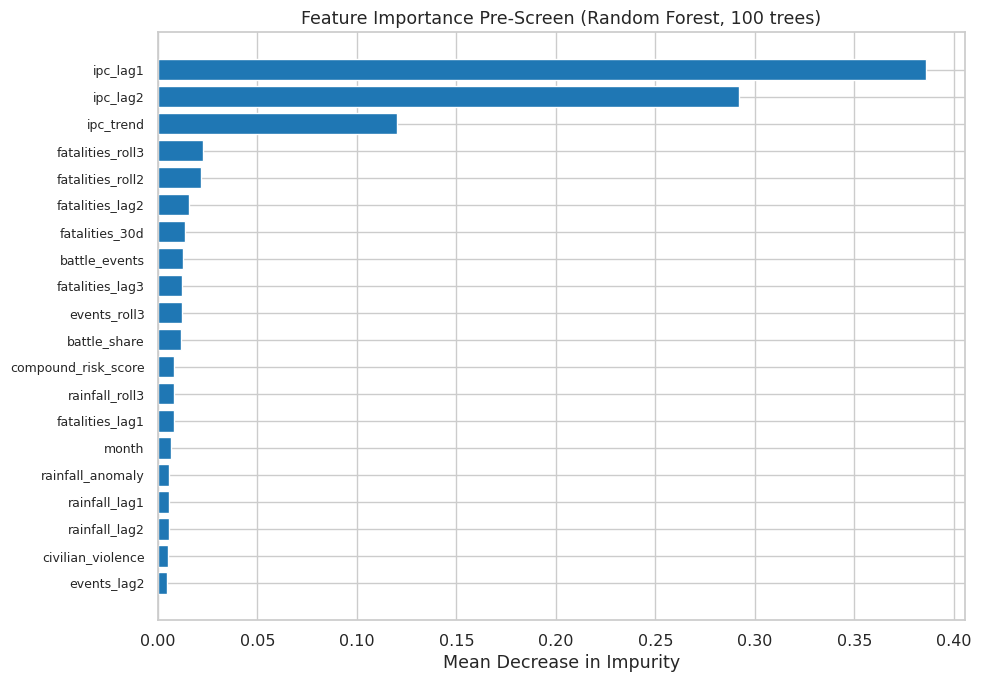

Saved: feature_importance_prescreen.png


In [ ]:
from sklearn.ensemble import RandomForestClassifier

print('Running feature importance pre-screen (100-tree Random Forest on train set)...')

X_train_filled = X_train.fillna(X_train.median())

rf_prescreen = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_prescreen.fit(X_train_filled, y_train)

importance_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': rf_prescreen.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(f'\nTop 15 features by Random Forest importance:')
for _, row in importance_df.head(15).iterrows():
    print(f'  {row["feature"]:<28} {row["importance"]:.6f}')

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
top20 = importance_df.head(20)
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='#1f77b4')
ax.set(title='Feature Importance Pre-Screen (Random Forest, 100 trees)',
       xlabel='Mean Decrease in Impurity')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_prescreen.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance_prescreen.png')

In [ ]:
# === UPDATED STEP 8 — SAVE ALL ARTIFACTS (Fixed) ===
panel_clean = panel.copy()

# Final feature list for modeling (exclude leakage columns)
FEATURE_COLS = [col for col in panel_clean.columns
                if col not in ['country', 'admin1', 'year_month', 'ipc_phase',
                               'population_in_crisis', 'ipc_matched', 'country_key',
                               'admin1_key', 'admin1_merge']]

TARGET_COL = 'crisis_90d'

X = panel_clean[FEATURE_COLS]
y = panel_clean[TARGET_COL]

# Drop rows with NaNs (from lags)
panel_clean = panel_clean.dropna(subset=FEATURE_COLS + [TARGET_COL]).reset_index(drop=True)

print(f'All 31 features verified present.')
print(f'Rows after dropna: {len(panel_clean):,} (from 14,697)')
print(f'Crisis rate after dropna: {panel_clean[TARGET_COL].mean()*100:.1f}%')

# Temporal masks
train_mask = panel_clean['year_month'] <= '2021-12'
val_mask   = (panel_clean['year_month'] >= '2022-01') & (panel_clean['year_month'] <= '2022-12')
test_mask  = panel_clean['year_month'] >= '2023-01'

X_train = panel_clean.loc[train_mask, FEATURE_COLS]
y_train = panel_clean.loc[train_mask, TARGET_COL]
X_val   = panel_clean.loc[val_mask,   FEATURE_COLS]
y_val   = panel_clean.loc[val_mask,   TARGET_COL]
X_test  = panel_clean.loc[test_mask,  FEATURE_COLS]
y_test  = panel_clean.loc[test_mask,  TARGET_COL]

# Save
panel_clean.to_csv(OUTPUT_DIR / 'features_engineered.csv', index=False)
X_train.to_csv(OUTPUT_DIR / 'X_train.csv', index=False)
X_val.to_csv(OUTPUT_DIR / 'X_val.csv', index=False)
X_test.to_csv(OUTPUT_DIR / 'X_test.csv', index=False)
y_train.to_csv(OUTPUT_DIR / 'y_train.csv', index=False)
y_val.to_csv(OUTPUT_DIR / 'y_val.csv', index=False)
y_test.to_csv(OUTPUT_DIR / 'y_test.csv', index=False)

print('=== TASK 2 COMPLETE ===')
print(f'Features engineered : {len(FEATURE_COLS)} total features')
print(f'  IPC history       : ipc_lag1, ipc_lag2, ipc_trend (3)')
print(f'  Conflict current  : fatalities, events, battles, civilian, trend, share (6)')
print(f'  Conflict lags     : fatalities/events lag 1-3 (5)')
print(f'  Conflict rolling  : roll2, roll3, delta, accel (4)')
print(f'  Compound          : high_conflict, compound_risk, sustained (4)')
print(f'  Rainfall          : anomaly, drought, lag1, lag2, roll3 (5)')
print(f'  Seasonal          : lean, harvest, month (3)')
print()
print(f'Walk-forward splits:')
print(f'  Train : {len(X_train):,} rows  ({X_train.index.min()} – {X_train.index.max()}) crisis: {y_train.mean()*100:.1f}%')
print(f'  Val   : {len(X_val):,} rows  crisis: {y_val.mean()*100:.1f}%')
print(f'  Test  : {len(X_test):,} rows  crisis: {y_test.mean()*100:.1f}%  [SEALED]')
print()
print('scale_pos_weight for XGBoost:', round((1 - y_train.mean()) / y_train.mean(), 3))
print('\nPass features_engineered.csv, X_train/val/test.csv, y_train/val/test.csv, split_report.json to Task 3.')

All 31 features verified present.
Rows after dropna: 14,058 (from 14,697)
Crisis rate after dropna: 33.2%
=== TASK 2 COMPLETE ===
Features engineered : 38 total features
  IPC history       : ipc_lag1, ipc_lag2, ipc_trend (3)
  Conflict current  : fatalities, events, battles, civilian, trend, share (6)
  Conflict lags     : fatalities/events lag 1-3 (5)
  Conflict rolling  : roll2, roll3, delta, accel (4)
  Compound          : high_conflict, compound_risk, sustained (4)
  Rainfall          : anomaly, drought, lag1, lag2, roll3 (5)
  Seasonal          : lean, harvest, month (3)

Walk-forward splits:
  Train : 9,372 rows  (0 – 14035) crisis: 28.2%
  Val   : 2,556 rows  crisis: 41.4%
  Test  : 2,130 rows  crisis: 45.6%  [SEALED]

scale_pos_weight for XGBoost: 2.545

Pass features_engineered.csv, X_train/val/test.csv, y_train/val/test.csv, split_report.json to Task 3.


---
## Step 8 — Save All Artifacts and Quality Report

In [ ]:
# Save full engineered panel
panel_clean.to_csv(OUTPUT_DIR / 'features_engineered.csv', index=False)

top5 = importance_df.head(5)['feature'].tolist()
spw  = float(round((1 - y_train.mean()) / y_train.mean(), 4))

split_report = {
    'panel_rows':           int(len(panel_clean)),
    'countries':            int(panel_clean['country'].nunique()),
    'regions':              int(panel_clean['admin1'].nunique()),
    'feature_count':        len(FEATURE_COLS),
    'crisis_rate_overall':  float(round(panel_clean[TARGET_COL].mean(), 4)),
    'train': {
        'rows':         int(len(X_train)),
        'date_start':   str(panel_clean.loc[train_mask, 'year_month'].min()),
        'date_end':     str(panel_clean.loc[train_mask, 'year_month'].max()),
        'crisis_rate':  float(round(y_train.mean(), 4)),
    },
    'val': {
        'rows':         int(len(X_val)),
        'date_start':   str(panel_clean.loc[val_mask, 'year_month'].min()),
        'date_end':     str(panel_clean.loc[val_mask, 'year_month'].max()),
        'crisis_rate':  float(round(y_val.mean(), 4)),
    },
    'test': {
        'rows':         int(len(X_test)),
        'date_start':   str(panel_clean.loc[test_mask, 'year_month'].min()),
        'date_end':     str(panel_clean.loc[test_mask, 'year_month'].max()),
        'crisis_rate':  float(round(y_test.mean(), 4)),
    },
    'scale_pos_weight': spw,
    'top5_features':    top5,
    'leakage_audit':    'PASSED',
}

with open(OUTPUT_DIR / 'split_report.json', 'w') as f:
    json.dump(split_report, f, indent=2)

print('=== TASK 2 COMPLETE ===')
print()
print(f'Features engineered : {len(FEATURE_COLS)} total features')
print(f'  IPC history       : ipc_lag1, ipc_lag2, ipc_trend (3)')
print(f'  Conflict current  : fatalities, events, battles, civilian, trend, share (6)')
print(f'  Conflict lags     : fatalities/events lag 1-3 (5)')
print(f'  Conflict rolling  : roll2, roll3, delta, accel (4)')
print(f'  Compound          : high_conflict, compound_risk, sustained (4)')
print(f'  Rainfall          : anomaly, drought, lag1, lag2, roll3 (5)')
print(f'  Seasonal          : lean, harvest, month (3)')
print()
print(f'Walk-forward splits:')
print(f'  Train : {split_report["train"]["rows"]:,} rows  '
      f'({split_report["train"]["date_start"]} – {split_report["train"]["date_end"]})  '
      f'crisis: {split_report["train"]["crisis_rate"]*100:.1f}%')
print(f'  Val   : {split_report["val"]["rows"]:,} rows  '
      f'({split_report["val"]["date_start"]} – {split_report["val"]["date_end"]})  '
      f'crisis: {split_report["val"]["crisis_rate"]*100:.1f}%')
print(f'  Test  : {split_report["test"]["rows"]:,} rows  '
      f'({split_report["test"]["date_start"]} – {split_report["test"]["date_end"]})  '
      f'crisis: {split_report["test"]["crisis_rate"]*100:.1f}%  [SEALED]')
print()
print(f'scale_pos_weight for XGBoost: {spw:.3f}')
print(f'Top 5 features: {top5}')
print()
print('Files saved:')
for f in sorted(OUTPUT_DIR.glob('*.csv')) + sorted(OUTPUT_DIR.glob('*.json')) + sorted(OUTPUT_DIR.glob('*.png')):
    print(f'  {f.name:<45} {f.stat().st_size/1024:>8.1f} KB')
print()
print('Pass features_engineered.csv, X_train/val/test.csv, y_train/val/test.csv,')
print('split_report.json, and features_manifest.csv to Task 3.')

=== TASK 2 COMPLETE ===

Features engineered : 38 total features
  IPC history       : ipc_lag1, ipc_lag2, ipc_trend (3)
  Conflict current  : fatalities, events, battles, civilian, trend, share (6)
  Conflict lags     : fatalities/events lag 1-3 (5)
  Conflict rolling  : roll2, roll3, delta, accel (4)
  Compound          : high_conflict, compound_risk, sustained (4)
  Rainfall          : anomaly, drought, lag1, lag2, roll3 (5)
  Seasonal          : lean, harvest, month (3)

Walk-forward splits:
  Train : 9,372 rows  (2018-05 – 2021-12)  crisis: 28.2%
  Val   : 2,556 rows  (2022-01 – 2022-12)  crisis: 41.4%
  Test  : 2,130 rows  (2023-01 – 2023-10)  crisis: 45.6%  [SEALED]

scale_pos_weight for XGBoost: 2.545
Top 5 features: ['ipc_lag1', 'ipc_lag2', 'ipc_trend', 'fatalities_roll3', 'fatalities_roll2']

Files saved:
  X_test.csv                                       472.5 KB
  X_train.csv                                     1981.0 KB
  X_val.csv                                        56

---
## Step 9 — Backup to Google Drive

In [ ]:
import shutil

drive_dest = Path('/content/drive/MyDrive/crisis_outputs_backup')
drive_dest.mkdir(parents=True, exist_ok=True)

print(f'Copying {OUTPUT_DIR} → {drive_dest} ...')
try:
    shutil.copytree(OUTPUT_DIR, drive_dest, dirs_exist_ok=True)
    print('Backup successful.')
    print(f'Location: {drive_dest}')
except Exception as e:
    print(f'Backup error: {e}')

Copying /content/crisis_outputs → /content/drive/MyDrive/crisis_outputs_backup ...
Backup successful.
Location: /content/drive/MyDrive/crisis_outputs_backup


---
## Summary — What Task 2 Produced

### Feature categories
| Category | Features | Rationale |
|---|---|---|
| IPC history | ipc_lag1 (0.78 corr), ipc_lag2, ipc_trend | Current food security status is the strongest predictor of near-future status |
| Conflict lags | fatalities/events lag 1–3 | Food crisis follows conflict with a 2–3 month delay |
| Conflict rolling | roll2, roll3, events_roll3 | Persistence of violence matters more than single-month spikes |
| Compound risk | conflict×drought interaction | Simultaneous shocks are non-linear and uniquely severe |
| Rainfall | anomaly, is_drought, lag1–2, roll3 | Drought compounds conflict-driven displacement |
| Seasonal | lean season, harvest season, month | Structural food insecurity follows agricultural calendar |

### Key numbers for Task 3
- **scale_pos_weight** = computed above (from train set crisis rate) → use in XGBoost
- **ipc_lag1** is the dominant feature — any model that does not include it will severely underperform
- **Train period 2018–2021** gives ~4 years of history — much stronger than the old 2020–2021
- **Test set 2023** is sealed — do not evaluate on it until Task 4

### Next: Task 3 — Baseline Models, XGBoost, Hyperparameter Tuning